1. Cargar el data set de la estructura de carpetas del proyecto

In [20]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from IPython.display import Image, display



In [ ]:
from sqlalchemy import create_engine, text


engine = create_engine(
    "mysql+pymysql://root:@127.0.0.1:3306/wdi_etl_db?charset=utf8mb4"
)

print("Conexión creada correctamente")

Conexión creada correctamente


#2.  Data Migration – Carga del Dataset a MySQL

En esta sección se realiza la fase de **Data Migration** del proceso ETL.  
El objetivo es cargar el dataset reducido del World Development Indicators (WDI) en una base de datos relacional (MySQL), cumpliendo con el requerimiento del proyecto.

Primero, se lee el archivo `WDI_10k_AGL.csv`, el cual contiene 10.000 registros y 69 columnas (features). Posteriormente, los datos se migran a la base de datos `wdi_etl_db`, creando la tabla `wdi_raw`. 

Finalmente, se ejecuta una consulta SQL para verificar que la carga se haya realizado correctamente, confirmando el número total de registros insertados.

Este paso garantiza que los datos estén almacenados en un sistema de gestión de bases de datos relacional, permitiendo su posterior transformación, análisis y consulta mediante SQL.

In [3]:


# Leer dataset
df = pd.read_csv("../data/raw/WDI_10k_AGL.csv")

print("Dimensiones del dataset:", df.shape)

# Cargar a MySQL
df.to_sql("wdi_raw", engine, if_exists="replace", index=False)

print(" Tabla 'wdi_raw' creada correctamente en MySQL")

# Verificar desde SQL
resultado = pd.read_sql("SELECT COUNT(*) AS total_filas FROM wdi_raw;", engine)
print(resultado)

Dimensiones del dataset: (10000, 69)
 Tabla 'wdi_raw' creada correctamente en MySQL
   total_filas
0        10000


#3. TRANSFORMACIÓN

##  Transform – Normalización de la tabla (formato Wide a Long)

El dataset WDI original está en formato **wide**, donde cada año (por ejemplo 1960, 1961, ..., 2022) aparece como una columna diferente.  
Para facilitar el análisis, consultas SQL y visualizaciones, se transforma la tabla a formato **long o tidy**, donde cada registro representa un valor único por:

- País  
- Indicador  
- Año  
- Valor  

El resultado se guarda como una nueva tabla llamada `wdi_clean`, que se considera la versión limpia y estructurada para el análisis posterior.

In [4]:


# 1) Identificar columnas que son años (por ejemplo "1960", "1961", ..., "2022")
year_cols = [c for c in df.columns if c.isdigit()]

print("Años detectados:", len(year_cols), "->", year_cols[:10], "...", year_cols[-5:])

# 2) Transformar a formato long
df_long = df.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

# 3) Tipos correctos
df_long["Year"] = df_long["Year"].astype(int)
df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")

print("Dimensiones tabla long:", df_long.shape)
df_long.head()

Años detectados: 65 -> ['1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969'] ... ['2020', '2021', '2022', '2023', '2024']
Dimensiones tabla long: (650000, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,1960,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,1960,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,1960,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,1960,NaN


# 4.  Guardar tabla limpia en MySQL

In [5]:
# Guardar tabla limpia
df_long.to_sql("wdi_clean", engine, if_exists="replace", index=False)

print(" Tabla 'wdi_clean' creada correctamente en MySQL")

# Verificar conteo
pd.read_sql("SELECT COUNT(*) AS total_filas FROM wdi_clean;", engine)

 Tabla 'wdi_clean' creada correctamente en MySQL


,total_filas
0,650000


#5. EDA desde MySQL

Exploración inicial de la tabla limpia

Ahora que ya transformamos los datos al formato correcto (long), vamos a empezar a explorarlos desde la base de datos.

En este punto quiero verificar cosas básicas pero importantes, como:

- Cuántos valores nulos existen
- Cuántos registros tienen datos reales
- Si la transformación quedó bien estructurada

Esto me ayuda a asegurar que los datos están listos para el análisis y que no hay problemas graves antes de hacer gráficos o consultas más avanzadas.

#5.1 Revisar nulos y conteo real

In [6]:
# Conteo total y valores nulos
pd.read_sql("""
SELECT 
    COUNT(*) AS total_registros,
    SUM(CASE WHEN Value IS NULL THEN 1 ELSE 0 END) AS valores_nulos,
    SUM(CASE WHEN Value IS NOT NULL THEN 1 ELSE 0 END) AS valores_validos
FROM wdi_clean;
""", engine)

,total_registros,valores_nulos,valores_validos
0,650000,455494.0,194506.0


5.1.1 Análisis de valores nulos

Después de transformar los datos, verifiqué cuántos valores estaban disponibles realmente.

El dataset contiene 650.000 registros en total, pero solo 194.506 tienen valores válidos. El resto corresponde a datos faltantes (NULL), lo cual es normal en bases de datos globales como WDI.

Esto ocurre porque no todos los países reportan todos los indicadores cada año, y algunos indicadores comenzaron a medirse en fechas posteriores.

Aunque hay muchos valores nulos, todavía tenemos una cantidad considerable de datos válidos para realizar análisis significativos.

##5.2 Promedio global por año

 Tendencia promedio por año

Ahora quiero analizar cómo se comportan los valores en promedio a lo largo del tiempo.

Para esto, calculo el promedio global de todos los valores disponibles por cada año. Esto me permite observar tendencias generales en los indicadores a lo largo del tiempo.

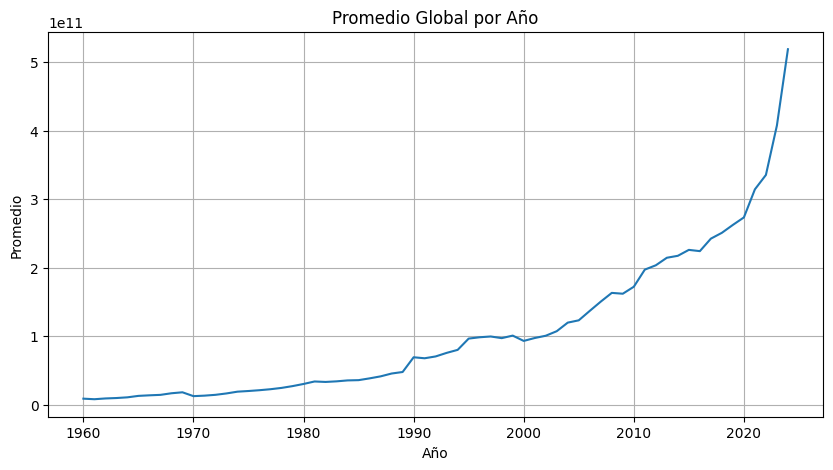

In [8]:

df_year = pd.read_sql("""
SELECT Year, AVG(Value) AS promedio
FROM wdi_clean
WHERE Value IS NOT NULL
GROUP BY Year
ORDER BY Year;
""", engine)

plt.figure(figsize=(10,5))
plt.plot(df_year["Year"], df_year["promedio"])
plt.title("Promedio Global por Año")
plt.xlabel("Año")
plt.ylabel("Promedio")
plt.grid(True)
plt.show()

5.2.1 Interpretación del promedio global

La gráfica muestra un crecimiento fuerte a lo largo del tiempo. Sin embargo, este resultado debe interpretarse con cuidado.

El promedio se calcula combinando todos los indicadores disponibles, incluyendo variables económicas muy grandes como el PIB en dólares, junto con indicadores pequeños como porcentajes o tasas.

Debido a esta mezcla de escalas diferentes, el promedio global aumenta considerablemente en los últimos años. Esto no significa necesariamente que todos los indicadores estén creciendo, sino que algunos valores económicos de gran magnitud influyen fuertemente en el cálculo.

Por esta razón, para análisis más precisos es recomendable estudiar indicadores específicos por separado.

## 5.3 indicadores que tienen más datos reportados

Indicadores con mayor cantidad de datos

Para entender mejor el dataset, voy a identificar cuáles indicadores tienen más valores reportados.

Esto permite saber qué variables tienen mayor cobertura histórica y cuáles son más confiables para análisis posteriores.

In [9]:
pd.read_sql("""
SELECT 
    `Indicator Name`,
    COUNT(Value) AS cantidad_datos
FROM wdi_clean
WHERE Value IS NOT NULL
GROUP BY `Indicator Name`
ORDER BY cantidad_datos DESC
LIMIT 10;
""", engine)

,Indicator Name,cantidad_datos
0,Age dependency ratio (% of working-age populat...,455
1,"Age dependency ratio, old (% of working-age po...",455
2,"Age dependency ratio, young (% of working-age ...",455
3,"Adolescent fertility rate (births per 1,000 wo...",448
4,"Birth rate, crude (per 1,000 people)",448
5,"Death rate, crude (per 1,000 people)",448
6,"Fertility rate, total (births per woman)",448
7,"Life expectancy at birth, female (years)",448
8,"Life expectancy at birth, male (years)",448
9,"Life expectancy at birth, total (years)",448


5.3.1 Indicadores con mayor cobertura

Al revisar los indicadores con más datos reportados, se observa que los primeros lugares corresponden principalmente a variables demográficas como tasas de dependencia, fertilidad, natalidad, mortalidad y esperanza de vida.

Esto indica que los indicadores poblacionales suelen tener una cobertura histórica más amplia y consistente en comparación con otros indicadores económicos o financieros.

En términos de análisis, esto significa que los indicadores demográficos pueden ser más confiables para estudiar tendencias a largo plazo dentro del dataset.

##5.4 Analizar un indicador específico en el tiempo
Life expectancy at birth, total (years)

Análisis específico: aqui revisamos la Esperanza de vida total

Ahora voy a analizar un indicador específico para observar su comportamiento a lo largo del tiempo.

En este caso, se selecciona la "Life expectancy at birth, total (years)", ya que es un indicador social importante y tiene buena cobertura en el dataset.

El objetivo es observar su tendencia promedio global a lo largo de los años.

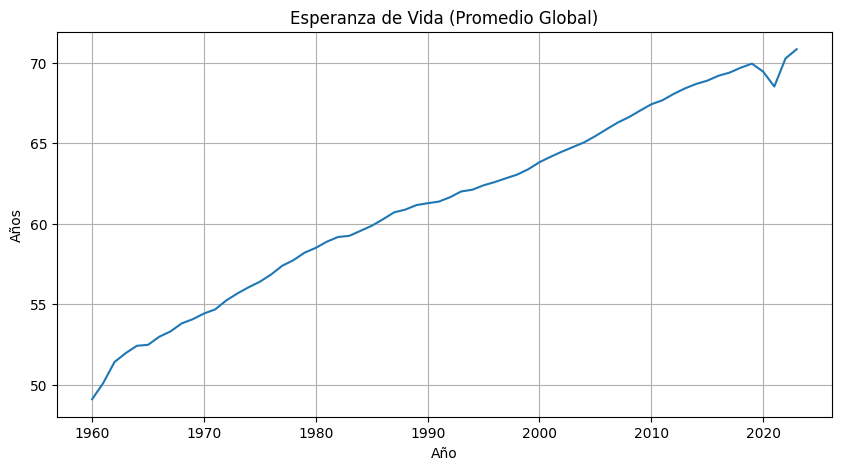

In [10]:
df_life = pd.read_sql("""
SELECT Year, AVG(Value) AS promedio
FROM wdi_clean
WHERE `Indicator Name` = 'Life expectancy at birth, total (years)'
AND Value IS NOT NULL
GROUP BY Year
ORDER BY Year;
""", engine)

plt.figure(figsize=(10,5))
plt.plot(df_life["Year"], df_life["promedio"])
plt.title("Esperanza de Vida (Promedio Global)")
plt.xlabel("Año")
plt.ylabel("Años")
plt.grid(True)
plt.show()

5.4.1 Análisis de la Esperanza de Vida

Al observar la gráfica, se puede notar que la esperanza de vida promedio mundial ha aumentado de forma bastante constante desde 1960.

En los años 60 el promedio estaba cerca de los 49 años, y con el paso del tiempo fue creciendo de manera progresiva hasta superar los 70 años en la actualidad. Esto muestra claramente una mejora global en las condiciones de salud, acceso a servicios médicos, nutrición y calidad de vida.

También se puede notar una pequeña caída alrededor de 2020, lo cual probablemente está relacionado con la pandemia del COVID-19, que impactó la mortalidad a nivel mundial.

En general, la tendencia es positiva y refleja un avance significativo en el desarrollo social y sanitario global durante las últimas décadas.

##6. Modelo Estrella WDI

6.1 Creación de la Dimensión País

En este paso voy a crear la primera dimensión del modelo estrella: la dimensión de países.

La idea del modelado dimensional es separar la información descriptiva (como nombres de países) de los valores numéricos que se analizan.

Aquí voy a generar una tabla única de países, asignándole una clave sustituta (country_key) que servirá para relacionarla con la tabla de hechos.


Tabla de Hechos:

Fact_WDI

* country_key

* indicator_key

* date_key

* value


Dimensiones:

* Dim_Country
* Dim_Indicator
* Dim_Date



In [11]:
# Crear dimensión país
dim_country = df_long[["Country Name", "Country Code"]].drop_duplicates().reset_index(drop=True)

# Crear surrogate key
dim_country["country_key"] = dim_country.index + 1

dim_country = dim_country[["country_key", "Country Name", "Country Code"]]

dim_country.head()

,country_key,Country Name,Country Code
0,1,Africa Eastern and Southern,AFE
1,2,Africa Western and Central,AFW
2,3,Arab World,ARB
3,4,Caribbean small states,CSS
4,5,Central Europe and the Baltics,CEB


6.1 Guardar en MySQL

In [12]:
dim_country.to_sql("dim_country", engine, if_exists="replace", index=False)

7

6.2 Crear Dimensión Indicador

Ahora voy a crear la dimensión de indicadores.

Cada indicador tiene un nombre y un código, pero en el modelo dimensional se les asigna una clave sustituta (indicator_key).

Esto permite mejorar el rendimiento en consultas y mantener un modelo tipo Data Warehouse.

In [13]:
dim_indicator = df_long[["Indicator Name", "Indicator Code"]].drop_duplicates().reset_index(drop=True)

dim_indicator["indicator_key"] = dim_indicator.index + 1

dim_indicator = dim_indicator[["indicator_key", "Indicator Name", "Indicator Code"]]

dim_indicator.head()

,indicator_key,Indicator Name,Indicator Code
0,1,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS
1,2,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS
2,3,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS
3,4,Access to electricity (% of population),EG.ELC.ACCS.ZS
4,5,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS


6.2.1 Guardar en MSQL

In [14]:
dim_indicator.to_sql("dim_indicator", engine, if_exists="replace", index=False)

1513

6.3 Crear Dimensión Fecha

En un modelo dimensional siempre se crea una dimensión de tiempo.

En este caso, como el dataset solo tiene el año, voy a construir una dimensión simple basada en el año.

Esta dimensión permitirá hacer análisis históricos de forma estructurada.

In [15]:
dim_date = df_long[["Year"]].drop_duplicates().reset_index(drop=True)

dim_date["date_key"] = dim_date.index + 1

dim_date = dim_date[["date_key", "Year"]]

dim_date.head()

,date_key,Year
0,1,1960
1,2,1961
2,3,1962
3,4,1963
4,5,1964


6.3.1 Guardar en Mysql

In [16]:
dim_date.to_sql("dim_date", engine, if_exists="replace", index=False)

65

6.4 Crear Tabla de Hechos

La tabla de hechos contiene las métricas numéricas que se desean analizar.

En este caso, la métrica principal es el valor del indicador.

Voy a relacionar cada registro con sus respectivas claves de país, indicador y fecha para construir la tabla central del modelo estrella.

In [17]:

fact_wdi = df_long.merge(dim_country, on=["Country Name", "Country Code"])
fact_wdi = fact_wdi.merge(dim_indicator, on=["Indicator Name", "Indicator Code"])
fact_wdi = fact_wdi.merge(dim_date, on="Year")


fact_wdi = fact_wdi[["country_key", "indicator_key", "date_key", "Value"]]

fact_wdi.head()

,country_key,indicator_key,date_key,Value
0,1,1,1,NaN
1,1,2,1,NaN
2,1,3,1,NaN
3,1,4,1,NaN
4,1,5,1,NaN


6.4.1 Guardar en Mysql

In [18]:
fact_wdi.to_sql("fact_wdi", engine, if_exists="replace", index=False)

650000

##7. MODELO RELACIONAL

En esta parte simplemente voy a mostrar la imagen del modelo relacional que representa cómo vienen organizados los datos en el origen (tipo OLTP).

La idea es dejar evidencia visual del punto de partida, porque así se entiende mejor qué tablas existen y cómo se relacionan antes de pasar al Data Warehouse (modelo estrella).

Crear el diagrama del modelo relacional


Como parte de la documentación del ETL, voy a generar un diagrama lógico del modelo relacional inicial.

Este modelo representa cómo están organizados los datos antes de aplicar el modelado dimensional.

Aquí simplemente se muestra la tabla principal `wdi_clean`, que contiene país, indicador, año y valor.

Esto sirve como evidencia del esquema relacional antes de pasar al modelo estrella.

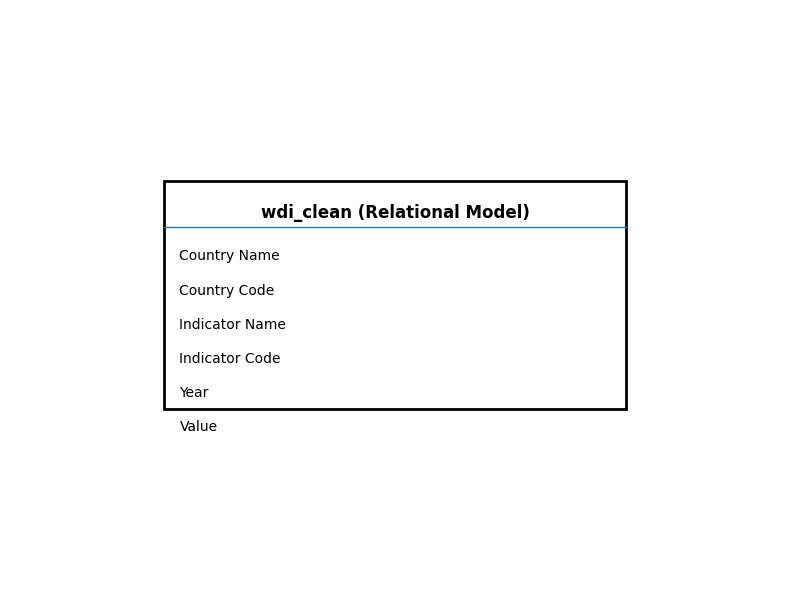

 Modelo relacional guardado en: ../docs\imagenes\modelo_relacional_wdi.png


In [23]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


ruta_base = "../"
carpeta_img = os.path.join(ruta_base, "docs", "imagenes")
os.makedirs(carpeta_img, exist_ok=True)


ruta_modelo_relacional = os.path.join(carpeta_img, "modelo_relacional_wdi.png")


def draw_table(ax, x, y, w, h, title, fields):
    rect = Rectangle((x, y), w, h, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h - 0.4, title, ha='center', va='top', fontsize=12, fontweight='bold')
    ax.plot([x, x+w], [y + h - 0.8, y + h - 0.8], linewidth=1)
    
    text_y = y + h - 1.2
    for f in fields:
        ax.text(x + 0.2, text_y, f, ha='left', va='top', fontsize=10)
        text_y -= 0.6


fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

draw_table(
    ax,
    x=2,
    y=3,
    w=6,
    h=4,
    title="wdi_clean (Relational Model)",
    fields=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code",
        "Year",
        "Value"
    ]
)

plt.tight_layout()
plt.savefig(ruta_modelo_relacional, dpi=200)
plt.show()

print(" Modelo relacional guardado en:", ruta_modelo_relacional)

7.1 diagrama estrella (DESTINO DW)

Ahora voy a crear un diagrama del modelo estrella, que es básicamente la forma “ordenada para análisis” (OLAP).

La idea es que la tabla central (fact) guarda el valor numérico principal (Value) y se conecta con tablas de dimensiones (country, indicator y date), que guardan la info descriptiva.

Esto hace que las consultas sean más rápidas y más fáciles de entender, como cuando queremos hacer análisis por país, por indicador o por año.

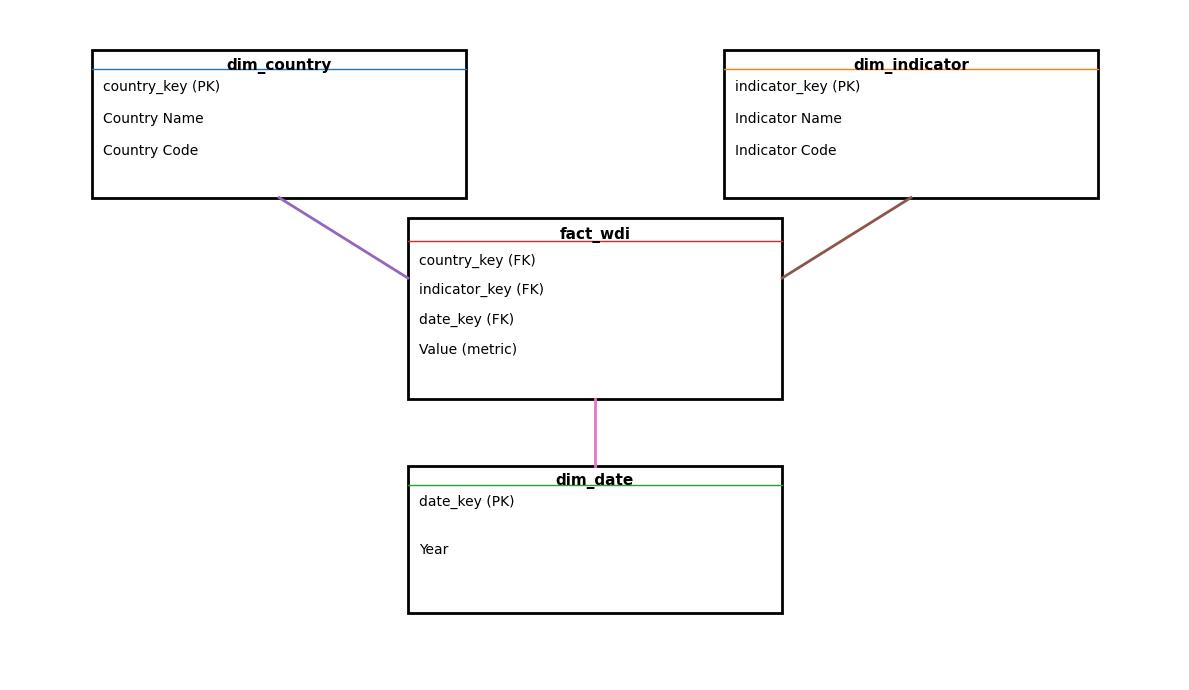

 Modelo estrella guardado en: ../docs\imagenes\modelo_estrella_wdi.png


In [21]:
from matplotlib.patches import Rectangle

# 1) Crear carpeta docs/imagenes si no existe
ruta_base = "../"  # notebook en /notebooks
carpeta_img = os.path.join(ruta_base, "docs", "imagenes")
os.makedirs(carpeta_img, exist_ok=True)

# 2) Ruta donde se guardará la imagen del modelo estrella
ruta_modelo_estrella = os.path.join(carpeta_img, "modelo_estrella_wdi.png")

# 3) Función para dibujar una tabla tipo cajita
def draw_table(ax, x, y, w, h, title, fields, fontsize=10):
    # caja
    rect = Rectangle((x, y), w, h, fill=False, linewidth=2)
    ax.add_patch(rect)
    
    # título
    ax.text(x + w/2, y + h - 0.05*h, title, ha='center', va='top', fontsize=fontsize+1, fontweight='bold')
    
    # línea separadora título
    ax.plot([x, x+w], [y + h - 0.13*h, y + h - 0.13*h], linewidth=1)
    
    # campos
    text_y = y + h - 0.2*h
    step = (h * 0.65) / max(len(fields), 1)
    for f in fields:
        ax.text(x + 0.03*w, text_y, f, ha='left', va='top', fontsize=fontsize)
        text_y -= step

# 4) Crear figura
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# 5) Coordenadas (modelo estrella)
# Dimensiones alrededor
draw_table(
    ax, x=0.7, y=7.2, w=3.2, h=2.2,
    title="dim_country",
    fields=[
        "country_key (PK)",
        "Country Name",
        "Country Code"
    ]
)

draw_table(
    ax, x=6.1, y=7.2, w=3.2, h=2.2,
    title="dim_indicator",
    fields=[
        "indicator_key (PK)",
        "Indicator Name",
        "Indicator Code"
    ]
)

draw_table(
    ax, x=3.4, y=1.0, w=3.2, h=2.2,
    title="dim_date",
    fields=[
        "date_key (PK)",
        "Year"
    ]
)

# Tabla de hechos al centro
draw_table(
    ax, x=3.4, y=4.2, w=3.2, h=2.7,
    title="fact_wdi",
    fields=[
        "country_key (FK)",
        "indicator_key (FK)",
        "date_key (FK)",
        "Value (metric)"
    ],
    fontsize=10
)

# 6) Dibujar relaciones (líneas)
# country -> fact
ax.plot([2.3, 3.4], [7.2, 6.0], linewidth=2)
# indicator -> fact
ax.plot([7.7, 6.6], [7.2, 6.0], linewidth=2)
# date -> fact
ax.plot([5.0, 5.0], [3.2, 4.2], linewidth=2)

# 7) Guardar imagen
plt.tight_layout()
plt.savefig(ruta_modelo_estrella, dpi=200)
plt.show()

print(" Modelo estrella guardado en:", ruta_modelo_estrella)

7.2 Diagrama estrella como imagen

Ya que el diagrama del modelo estrella fue creado y guardado como imagen, ahora lo muestro en el notebook.

Esto sirve como evidencia visual del Data Warehouse final y deja claro que sí se aplicó modelado dimensional tipo estrella.

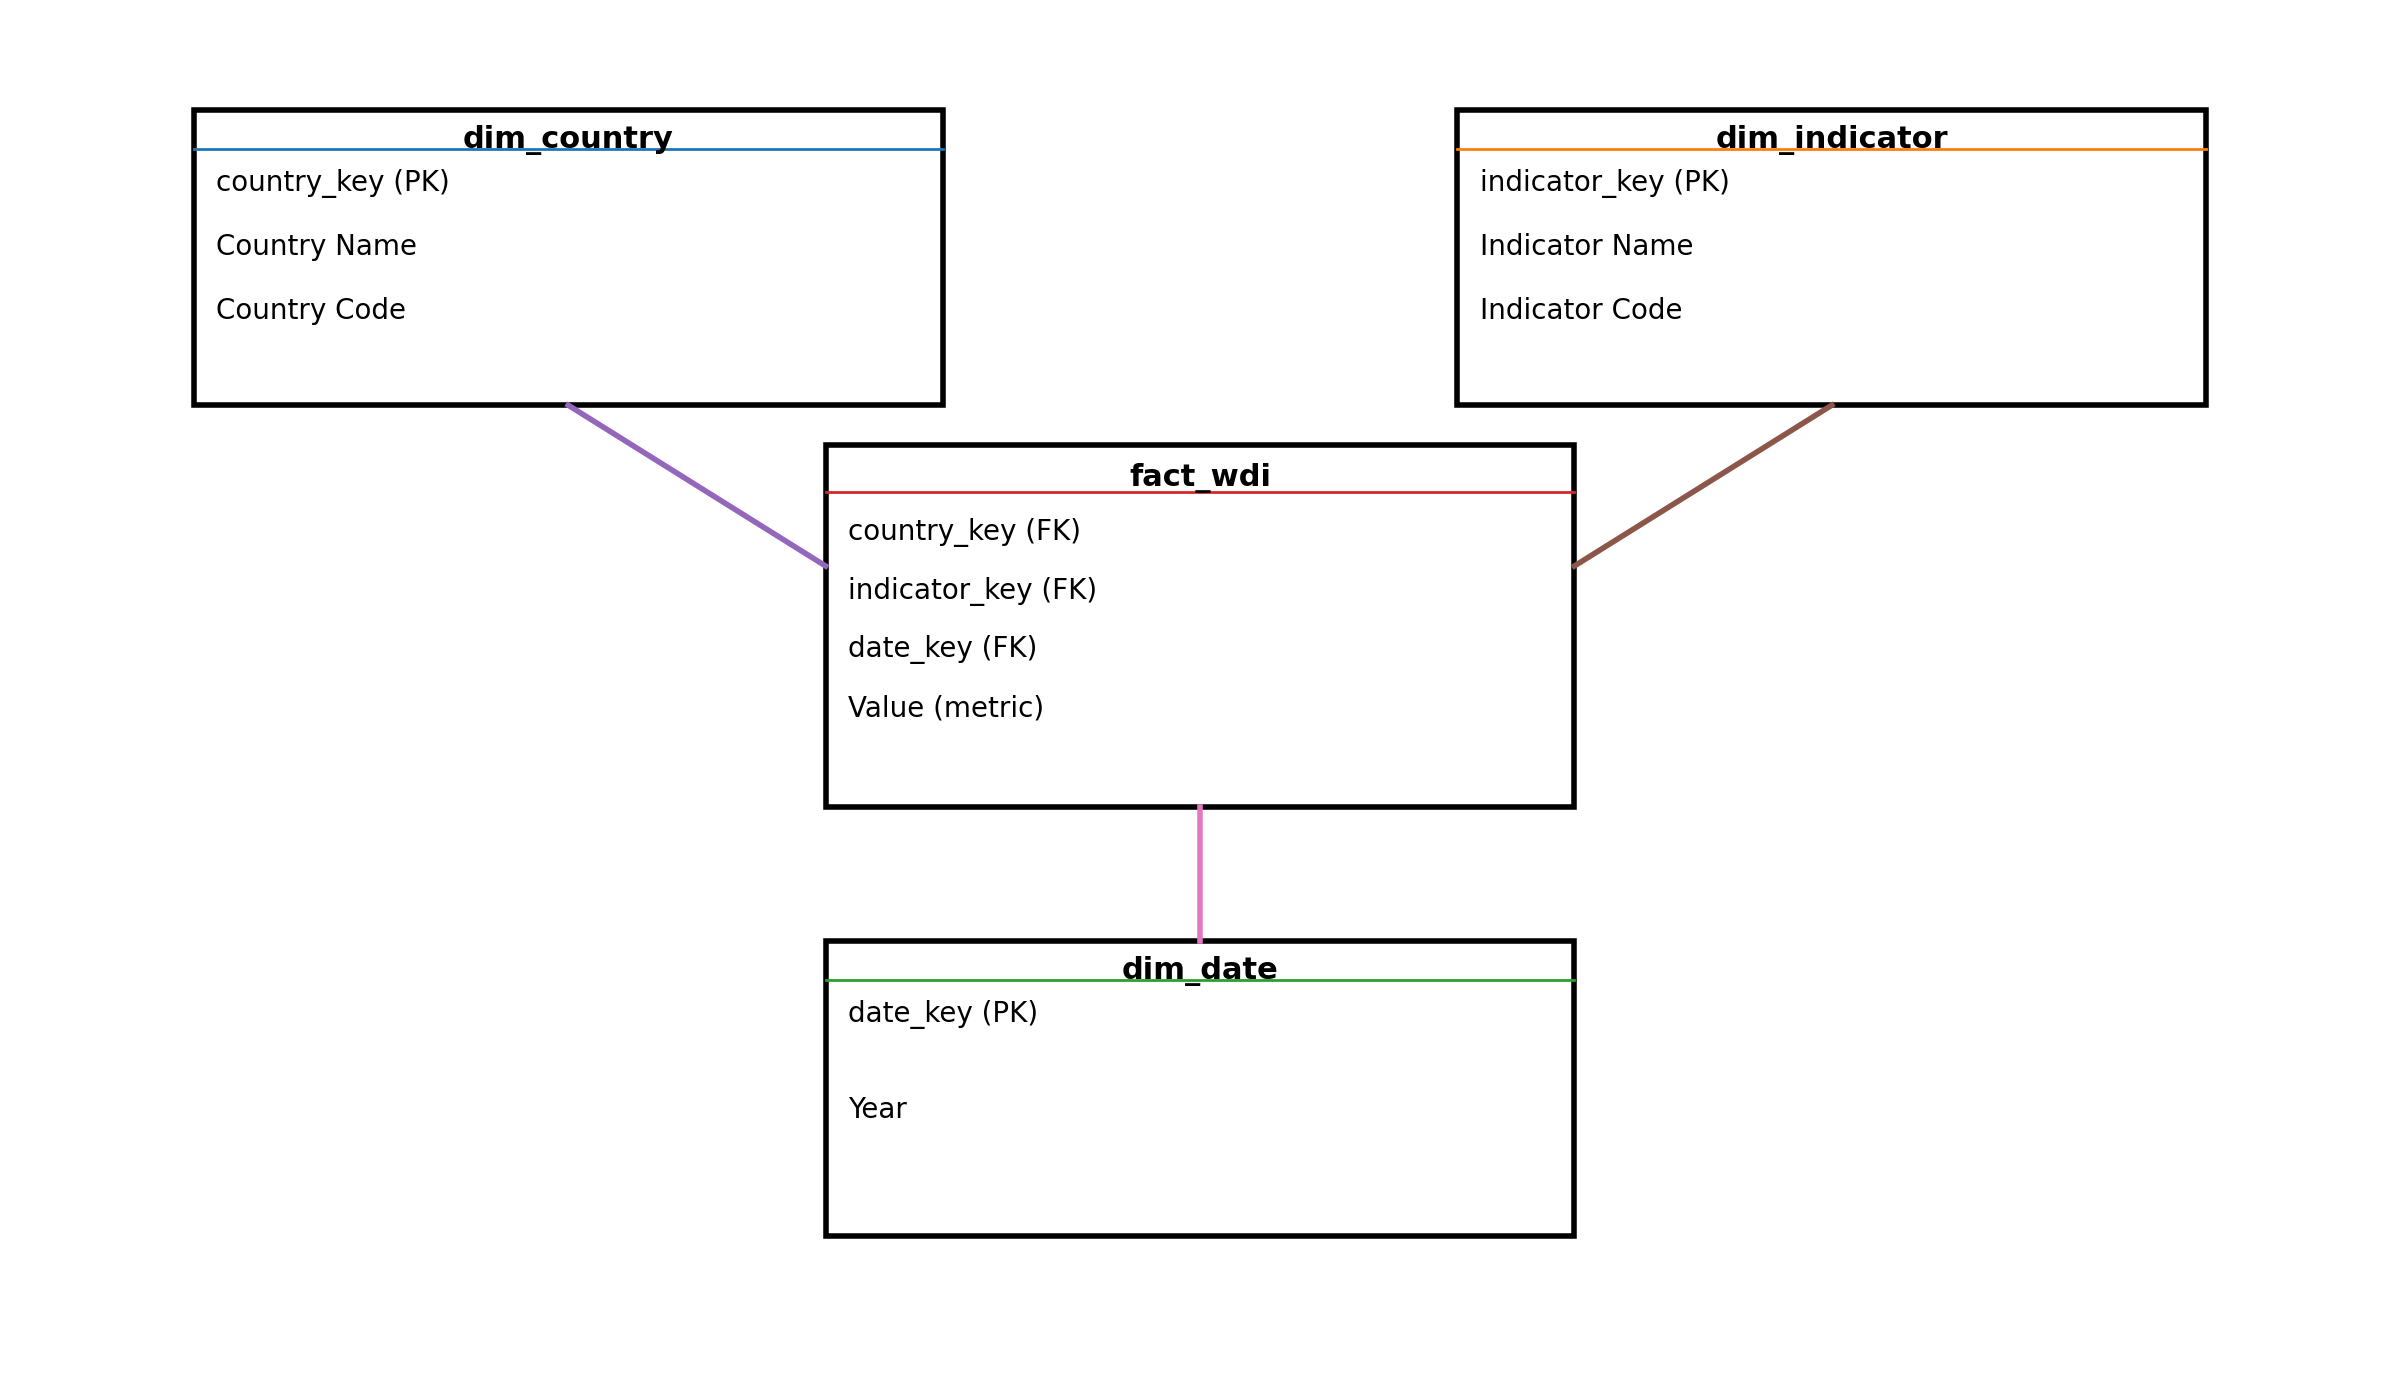

In [22]:
from IPython.display import Image, display
import os

ruta_base = "../"
ruta_modelo_estrella = os.path.join(ruta_base, "docs", "imagenes", "modelo_estrella_wdi.png")

display(Image(ruta_modelo_estrella))